# analysis.modules

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import numpy as np
import igraph  as ig
import networkx as nx
import random
from scipy import stats
habitat_palette = {
    "Crop": "#0CAB7B", 
    "Edge": "#3A8DFA", 
    "Oak": "#FB2231",
    "Wasteland": "#FFC51F"
}
import matplotlib.pyplot as plt
from yaml import load, Loader
from daforfer import DaforferDB
import re

conf = load(open('conf.yaml'), Loader)
db = DaforferDB(conf['database'])
si = DaforferDB(conf['si'])
si.toc()

plt.rcParams['svg.fonttype'] = 'none'
db.toc().df()
plt.rcParams['svg.fonttype'] = 'none'

## Module-habitat association

Previous analysis has shown that the virus-bacteria-host network is more modular than expected. Considering that, we might wonder about the features of the different modules. A specific property that was tested in McLeish25 is whether modules are associated to specific habitats. In McLeish24 words:


```{markdown}
observed network modularity (Q) that was significantly higherthan expected by chance
(one-samplet-test,t=699.67,df=999,P-value<0.0001) and showed a significant
(Fisher’sexact test;P=0.0005) relationship between network moduleand habitat category
```

We will run a test with the same goal. Our variable will be the number of habitat-specific links associated to each module. Our null
hypothesis is that there is not an association between modules and habitats, so the number of links of each
different habitat will be the same; our alternative hypothesis will be the oposite.

First, we need to load the different modules. We had computed them using an R script, and the results from that R script is a file containing rows and columns associated to microorganisms and hosts. We need to carefully check that the names employed here match the names that we have been using before, considering the slightly different origins of the virus network dataset.

In [7]:
modules = pd.read_csv("scratch/modules.virusbact.weighted.csv", sep='\t')#.pivot(index='index', columns='type', values='value')
# modules = modules.set_index('value')
module_index = modules['index'].unique()
host_modules = modules.query('type == "row"')[['index', 'value']]
org_modules = modules.query('type == "col"')[['index', 'value']]
org_modules

,index,value
1,1,Sphingomonas sp. Leaf28
4,2,Herbaspirillum seropedicae
5,2,Marmoricola sp. Leaf446
6,2,Methylobacterium sp. Leaf104
7,2,Pedobacter sp. Leaf194
...,...,...
392,17,Stenotrophomonas maltophilia
393,17,Streptomyces griseorubiginosus
394,17,ToLCNDV
395,17,Xaviernesmea rhizosphaerae


It seems that viruses are named using the acronym, which is a bit of an issue, because we have declared them using their scientific names in our tables. We will need to translate them later. For now, we can simply skip this issue.

Now we can proceed to load the multigraph network using NetworkX. We will use NetworkX subgraph to extract the modules by considering the hosts and microorganisms associated to each node. Then, we will simply count the number of edges associated to each habiat.

In [8]:
M = nx.read_graphml("output/network.virusbact-host.multigraph.graphml")
module_habitat_df = []

for mod in module_index:

    mod_hosts = host_modules.query(f'index == {mod}')['value'].to_list()
    mod_org = org_modules.query(f'index == {mod}')['value'].to_list()

    nodes = set(list(set(mod_hosts + mod_org)))
    module = M.subgraph(nodes)

    module_habitat_df.append(dict(
        crop = [u['habitat'] for _, _, u in module.edges(data=True)].count('Crop'),
        edge = [u['habitat'] for _, _, u in module.edges(data=True)].count('Edge'),
        wasteland = [u['habitat'] for _, _, u in module.edges(data=True)].count('Wasteland'),
        oak = [u['habitat'] for _, _, u in module.edges(data=True)].count('Oak'),
    ))

module_habitat_df = pd.DataFrame.from_records(module_habitat_df)
module_habitat_df

,crop,edge,wasteland,oak
0,1,0,0,0
1,0,0,3,2
2,0,0,2,2
3,3,26,3,0
4,0,0,0,3
5,0,0,4,0
6,12,75,16,1
7,16,130,2,1
8,1,9,12,0
9,0,1,18,17


Now, in principle, we are ready to run the statistical test.

In [9]:
module_habitat_chi2_test = stats.chi2_contingency(module_habitat_df)

print("dof       = {:12d}".format(module_habitat_chi2_test.dof))
print("statistic = {:12.4e}".format(module_habitat_chi2_test.statistic))
print("p-value   = {:12.4e}".format(module_habitat_chi2_test.pvalue))
print("sign      =      {0}".format(module_habitat_chi2_test.pvalue < 0.05))

dof       =           48
statistic =   6.5698e+02
p-value   =  6.8772e-108
sign      =      True


Therefore, we can conclude that **modules are associated to specific habitats**

## Module-Organism relationship

The second query that we will consider is whether modules are associated to habitats. To do so, we will map each organism to its domain of life. This might be an issue for viruses, as their names use acronyms, which is a different format than the one that we consider. Therefore, we need to run some tweaks.

In [10]:
virus_OTUs = pd.read_csv("input/network.mcleish24.nodes.csv", sep="\s+").query('type == "virus"')['taxon'].unique().tolist()
PAB_OTUs = db.conn.sql('SELECT * FROM D_PABOTUs').df()['scientific_name'].unique().tolist()
host_names = db.conn.sql('SELECT * FROM D_sites').df()['host_taxon'].unique().tolist()

module_org_df = []

for _mod in module_index:

    _mod_hosts = host_modules.query(f'index == {_mod}')['value'].to_list()
    _mod_org = org_modules.query(f'index == {_mod}')['value'].to_list()

    module_org_df.append(
        dict(
            plant = len([h for h in _mod_hosts if h in host_names]),
            virus = len([h for h in _mod_org if h in virus_OTUs]),
            bacteria = len([h for h in _mod_org if h in PAB_OTUs]),
        )
    )

module_org_df = pd.DataFrame.from_records(module_org_df)
module_org_df

<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:1: SyntaxWarning: invalid escape sequence '\s'
/var/folders/xl/z7y434d524s8xpvqnb0gst580000gn/T/ipykernel_50823/862506451.py:1: SyntaxWarning: invalid escape sequence '\s'
  virus_OTUs = pd.read_csv("input/network.mcleish24.nodes.csv", sep="\s+").query('type == "virus"')['taxon'].unique().tolist()


,plant,virus,bacteria
0,1,0,1
1,2,0,4
2,3,2,2
3,3,2,29
4,1,0,3
5,3,0,2
6,12,23,15
7,18,24,11
8,3,15,1
9,8,9,7


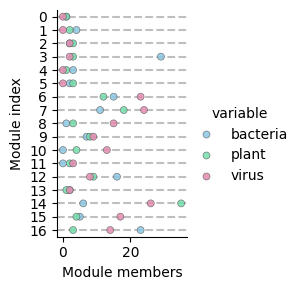

In [11]:
_modules_melt = module_org_df.reset_index().melt(id_vars='index', value_vars=['bacteria', 'plant', 'virus', ])
_modules_melt['index'] = _modules_melt['index'].astype(str)
_g = sns.catplot(
    _modules_melt, y='index', x='value', hue='variable', marker='o', 
    height=3.0, aspect=0.75, jitter=0.0, alpha=0.85,
    palette= {
        'plant': "#73deac",
        'virus': "#e58bb1",
        'bacteria': "#8bc8e5"
    }, **{'linewidth':0.5}
)
for i in range(17):
    _g.axes[0, 0].axhline(i, color='gray', linestyle='--', alpha=0.5)

_g.set_xlabels("Module members")
_g.set_ylabels("Module index")
# g.savefig("figures/catplot.module-composition.colbytype.svg")

In [12]:
module_org_chi2_test = stats.chi2_contingency(module_org_df)

print("dof       = {:12d}".format(module_org_chi2_test.dof))
print("statistic = {:12.4e}".format(module_org_chi2_test.statistic))
print("p-value   = {:12.4e}".format(module_org_chi2_test.pvalue))
print("sign      =      {0}".format(module_org_chi2_test.pvalue < 0.05))

dof       =           32
statistic =   1.4118e+02
p-value   =   1.1466e-15
sign      =      True


In [13]:
module_org_chi2_test_2 = stats.chi2_contingency(module_org_df.drop(columns=['plant']))

print("dof       = {:12d}".format(module_org_chi2_test_2.dof))
print("statistic = {:12.4e}".format(module_org_chi2_test_2.statistic))
print("p-value   = {:12.4e}".format(module_org_chi2_test_2.pvalue))
print("sign      =      {0}".format(module_org_chi2_test_2.pvalue < 0.05))

dof       =           16
statistic =   9.0125e+01
p-value   =   2.3730e-12
sign      =      True


## Modules and cooccurrences

To study of how frequent are cooccurrences within the modules, we need to convert the names of viruses so we can match them against the cooccurrence network.

In [14]:
_M_virus_nodes = [{'node': node, **node_data} for node, node_data in M.nodes(data=True) if node_data['role'] == 'virus']
_M_virus_nodes = pd.DataFrame.from_records(_M_virus_nodes)
_virus_hits = pd.read_csv("output/hits.virus.csv", sep=";").dropna(subset=['acronym'])
_virus_hits['acronym'] = _virus_hits['acronym'].apply(lambda x: re.sub("\d", "", x))
virus_rename_dict = {}
for _, _data in pd.merge(
    _M_virus_nodes.drop(columns=['scientific_name']), _virus_hits, left_on='node', right_on='acronym'
)[['node', 'scientific_name']].iterrows():
    virus_rename_dict[_data['node']] = _data['scientific_name']
virus_rename_dict


# M = nx.relabel_nodes(M, virus_rename_dict)

<>:4: SyntaxWarning: invalid escape sequence '\d'
<>:4: SyntaxWarning: invalid escape sequence '\d'
/var/folders/xl/z7y434d524s8xpvqnb0gst580000gn/T/ipykernel_50823/898259013.py:4: SyntaxWarning: invalid escape sequence '\d'
  _virus_hits['acronym'] = _virus_hits['acronym'].apply(lambda x: re.sub("\d", "", x))


{'CMV': 'Cucumber mosaic virus RNA 3',
 'PZSV': 'Pelargonium zonate spot virus RNA 3',
 'TAV': 'Tomato aspermy virus RNA 3',
 'PMoV': 'Parietaria mottle virus RNA 3',
 'CmEV': 'Cucumis melo endornavirus',
 'BYDV_GAV': 'Barley yellow dwarf virus - GAV',
 'BYDV_MAV': 'Barley yellow dwarf virus - MAV',
 'BYDV_PAS': 'Barley yellow dwarf virus - PAS',
 'BYDV_PAV': 'Barley yellow dwarf virus - PAV',
 'WMV': 'Watermelon mosaic virus',
 'CLLV': 'Calla lily latent virus',
 'RuCMV': 'Rubus chlorotic mottle virus',
 'SbMV': 'Soybean mosaic virus',
 'TMGMV': 'Tobacco mild green mosaic virus',
 'BCMV': 'Bean common mosaic virus',
 'GMMV': 'Gayfeather mild mottle virus RNA 3',
 'CABMV': 'Cowpea aphid-borne mosaic virus',
 'BYDV_KerII': 'Barley yellow dwarf virus Ker-II',
 'TelMV': 'Telosma mosaic virus',
 'TMV': 'Tobacco mosaic virus',
 'BWYV': 'Beet western yellows virus',
 'PMMoV': 'Pepper mild mottle virus',
 'IJGMV': 'Iranian johnsongrass mosaic virus',
 'FVY': 'Fritillary virus Y',
 'SPCSV': 'S

In [15]:
M_renamed = nx.relabel_nodes(M, virus_rename_dict)
modules['value'] = modules.value.replace(virus_rename_dict)
modules

,index,type,value
0,1,row,Klasea pinnatifida
1,1,col,Sphingomonas sp. Leaf28
2,2,row,Aphyllanthes monspeliensis
3,2,row,Hieracium pilosella
4,2,col,Herbaspirillum seropedicae
...,...,...,...
392,17,col,Stenotrophomonas maltophilia
393,17,col,Streptomyces griseorubiginosus
394,17,col,ToLCNDV
395,17,col,Xaviernesmea rhizosphaerae


In [16]:
C = nx.read_graphml("output/network.coocurrence.virusbact-bylibrary.trans.graphml")
modules['is_in_cooccurrence'] = modules['value'].apply(lambda x: x in C.nodes())
modules.value_counts(['is_in_cooccurrence', 'type'])

is_in_cooccurrence  type
False               col     247
                    row     112
True                col      38
Name: count, dtype: int64

In [17]:
cooccurrence_in_modules = []
for _m in range(1, 18):
    _u = C.subgraph(modules.query(f'index == {_m:d}')['value'].tolist())
    cooccurrence_in_modules.append(
        {'index': str(_m), 'number_cooccurrences': _u.number_of_edges()}
    )
cooccurrence_in_modules = pd.DataFrame.from_records(cooccurrence_in_modules)
cooccurrence_in_modules

,index,number_cooccurrences
0,1,0
1,2,0
2,3,0
3,4,0
4,5,0
5,6,0
6,7,1
7,8,9
8,9,0
9,10,0


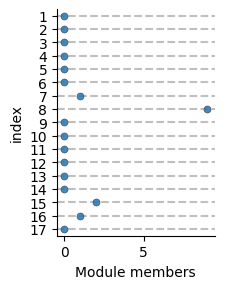

In [18]:
_g = sns.catplot(
    cooccurrence_in_modules, y='index', x='number_cooccurrences',  marker='o', 
    height=3.0, aspect=0.75, jitter=0.0, alpha=0.85, **{'linewidth':0.5}
)
for _i in range(17):
    _g.axes[0, 0].axhline(_i, color='gray', linestyle='--', alpha=0.5)

_g.set_xlabels("Module members")
# g.set_ylabels("Module index")
# g.savefig("figures/catplot.module-composition.colbytype.svg")

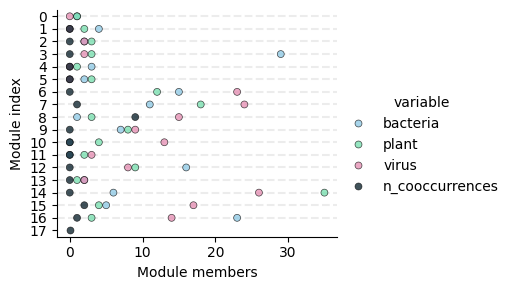

In [19]:
cooccurrence_in_modules['variable'] = 'n_cooccurrences'
_cooccurrence_in_modules_mod = cooccurrence_in_modules.rename(columns={'number_cooccurrences': 'value'})
_modules_melt = module_org_df.reset_index().melt(id_vars='index', value_vars=['bacteria', 'plant', 'virus', ])
_modules_melt['index'] = _modules_melt['index'].astype(str)
_modules_melt = pd.concat([_modules_melt, _cooccurrence_in_modules_mod]).reset_index()
_g = sns.catplot(
    _modules_melt, y='index', x='value', hue='variable', marker='o', 
    height=3.0, aspect=1.25, jitter=0.0, alpha=0.75,
    palette= {
        'plant': "#73deac",
        'virus': "#e58bb1",
        'bacteria': "#8bc8e5",
        'n_cooccurrences': "#011924"
    }, **{'linewidth':0.5}
)
for _i in range(17):
    _g.axes[0, 0].axhline(_i, color='gray', linestyle='--', alpha=0.15)

_g.set_xlabels("Module members")
_g.set_ylabels("Module index")
# g.savefig("figures/catplot.module-composition.colbytype.svg")
_g

In [20]:
cooccurrence_in_modules['number_cooccurrences'].sum()

np.int64(13)

In [21]:
si.close()
db.close()